In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

df = pd.read_csv('/content/public_dataset.csv')
print(df.shape)
print(df.head())

(184138, 3)
  hotel_id                                 supplier_room_name  target
0       17  комфорт для гостей с ограниченными физическими...       1
1       17                                 стандарт 1-местный       1
2       17                                  комфорт 2-местный       1
3       17                                             делюкс       1
4       17                                             бизнес       1


In [2]:
print("Размер:", df.shape)
print("\nТипы данных:\n", df.dtypes)
print("\nПропуски:\n", df.isnull().sum())
print("\nУникальных отелей:", df['hotel_id'].nunique())
print("\nРаспределение target:\n", df['target'].value_counts(normalize=True))
print("\nСтроки с пустыми supplier_room_name:", (df['supplier_room_name'].isnull() | (df['supplier_room_name'] == '')).sum())

Размер: (184138, 3)

Типы данных:
 hotel_id              object
supplier_room_name    object
target                 int64
dtype: object

Пропуски:
 hotel_id               0
supplier_room_name    18
target                 0
dtype: int64

Уникальных отелей: 4238

Распределение target:
 target
1    0.515934
0    0.484066
Name: proportion, dtype: float64

Строки с пустыми supplier_room_name: 18


In [3]:
# Удаляем строки с пустым или отсутствующим supplier_room_name
df_clean = df.dropna(subset=['supplier_room_name'])
df_clean = df_clean[df_clean['supplier_room_name'].str.strip() != '']
print(f"После удаления: {df_clean.shape}")

# Проверим, что пропусков больше нет
print(f"Осталось пустых: {(df_clean['supplier_room_name'].isnull() | (df_clean['supplier_room_name'].str.strip() == '')).sum()}")

После удаления: (184120, 3)
Осталось пустых: 0


Уникальных отелей: 4222
Максимум комнат на отель: 6736
Минимум комнат на отель: 1
Медиана: 3
Среднее: 43.6


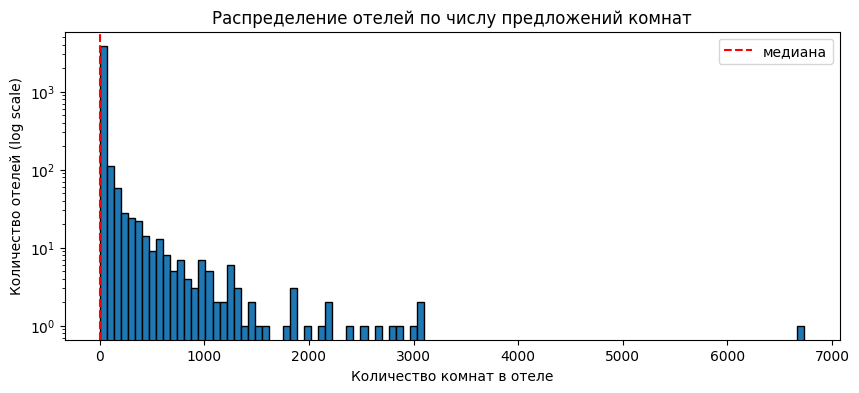

Топ-10 отелей по числу комнат:
     hotel_id  rooms_count  target_mean
1973     3484         6736     0.351989
1385     2293         3053     0.439240
3494     5851         3034     0.518128
3304     5595         3001     0.826724
3131     5364         2875     0.689739
1179     2140         2827     0.441104
1710     3102         2660     0.163910
1126     2087         2534     0.461326
922      1859         2410     0.582158
2982     5085         2209     0.931643
Средняя доля target=1 в маленьких отелях (≤10 комн): 0.775
Средняя доля target=1 в больших отелях (≥100 комн): 0.514


In [4]:
hotel_stats = df_clean.groupby('hotel_id').agg(
    rooms_count=('supplier_room_name', 'count'),
    target_mean=('target', 'mean')
).reset_index()

print(f"Уникальных отелей: {hotel_stats['hotel_id'].nunique()}")
print(f"Максимум комнат на отель: {hotel_stats['rooms_count'].max()}")
print(f"Минимум комнат на отель: {hotel_stats['rooms_count'].min()}")
print(f"Медиана: {hotel_stats['rooms_count'].median():.0f}")
print(f"Среднее: {hotel_stats['rooms_count'].mean():.1f}")

# График распределения
plt.figure(figsize=(10,4))
plt.hist(hotel_stats['rooms_count'], bins=100, log=True, edgecolor='black')
plt.xlabel('Количество комнат в отеле')
plt.ylabel('Количество отелей (log scale)')
plt.title('Распределение отелей по числу предложений комнат')
plt.axvline(hotel_stats['rooms_count'].median(), color='r', linestyle='--', label='медиана')
plt.legend()
plt.show()

# Топ-10 отелей с наибольшим числом комнат
print("Топ-10 отелей по числу комнат:")
print(hotel_stats.nlargest(10, 'rooms_count')[['hotel_id', 'rooms_count', 'target_mean']])

# Сравнение доли target=1 у маленьких и больших отелей
small = hotel_stats[hotel_stats['rooms_count'] <= 10]['target_mean']
large = hotel_stats[hotel_stats['rooms_count'] >= 100]['target_mean']
print(f"Средняя доля target=1 в маленьких отелях (≤10 комн): {small.mean():.3f}")
print(f"Средняя доля target=1 в больших отелях (≥100 комн): {large.mean():.3f}")

In [5]:
# Базовые статистики по rooms_count
print("Квантили rooms_count:")
for q in [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f"  {q*100:.0f}%: {hotel_stats['rooms_count'].quantile(q):.0f}")

# Предлагаемые интервалы (логарифмическая шкала)
bins = [1, 10, 50, 200, 1000, 5000, hotel_stats['rooms_count'].max()+1]
labels = ['1-10', '11-50', '51-200', '201-1000', '1001-5000', '5000+']
hotel_stats['size_group'] = pd.cut(hotel_stats['rooms_count'], bins=bins, labels=labels, right=False)

# Количество отелей в каждой группе
print("\nКоличество отелей по группам размера:")
size_counts = hotel_stats['size_group'].value_counts().sort_index()
print(size_counts)

# Также выведем долю от всех отелей
print("\nДоля отелей в группах (%):")
print((size_counts / len(hotel_stats) * 100).round(1))

Квантили rooms_count:
  10%: 1
  25%: 1
  50%: 3
  75%: 8
  90%: 47
  95%: 161
  99%: 971

Количество отелей по группам размера:
size_group
1-10         3309
11-50         507
51-200        221
201-1000      145
1001-5000      39
5000+           1
Name: count, dtype: int64

Доля отелей в группах (%):
size_group
1-10         78.4
11-50        12.0
51-200        5.2
201-1000      3.4
1001-5000     0.9
5000+         0.0
Name: count, dtype: float64


             0      1  total  percent_1
cat_new                                
0-99      7742  20513  28255  72.599540
100-999  43826  38559  82385  46.803423
>=1000   37565  35915  73480  48.877246


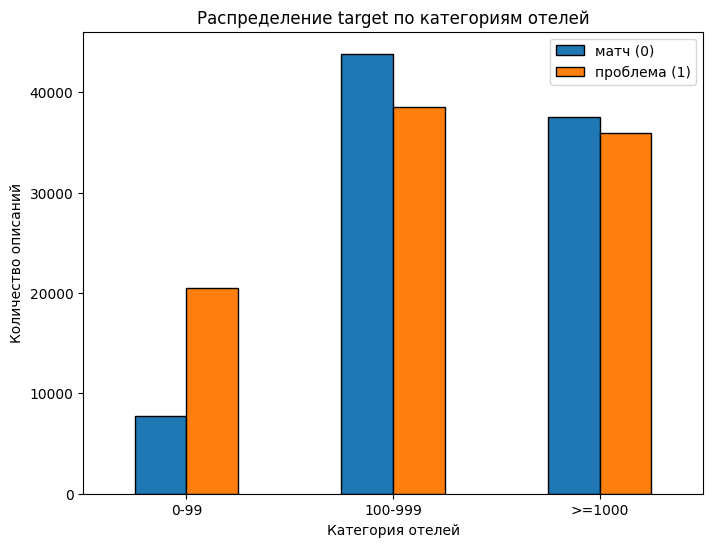

In [6]:
# Подсчёт количества комнат на отель
hotel_stats = df_clean.groupby('hotel_id').size().reset_index(name='rooms_count')
rooms_dict = dict(zip(hotel_stats['hotel_id'], hotel_stats['rooms_count']))
df_clean['rooms_count'] = df_clean['hotel_id'].map(rooms_dict)

# Создание категории cat_new
def get_cat(rooms):
    if rooms < 100:
        return '0-99'
    elif rooms < 1000:
        return '100-999'
    else:
        return '>=1000'

df_clean['cat_new'] = df_clean['rooms_count'].apply(get_cat)

# Теперь твой код (без изменений)
counts = df_clean.groupby(['cat_new', 'target']).size().unstack(fill_value=0)
counts.columns = [0, 1]
counts['total'] = counts[0] + counts[1]
counts['percent_1'] = counts[1] / counts['total'] * 100
print(counts)

counts[[0,1]].plot(kind='bar', figsize=(8,6), edgecolor='black', rot=0)
plt.xlabel('Категория отелей')
plt.ylabel('Количество описаний')
plt.title('Распределение target по категориям отелей')
plt.legend(['матч (0)', 'проблема (1)'])
plt.show()

Средняя длина описания (символы) по группам отелей:
cat_new
0-99       51.1
100-999    77.6
>=1000     84.8
Name: len_chars, dtype: float64


/tmp/ipykernel_1218/1085780331.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='target', y='len_chars', palette='Set2')


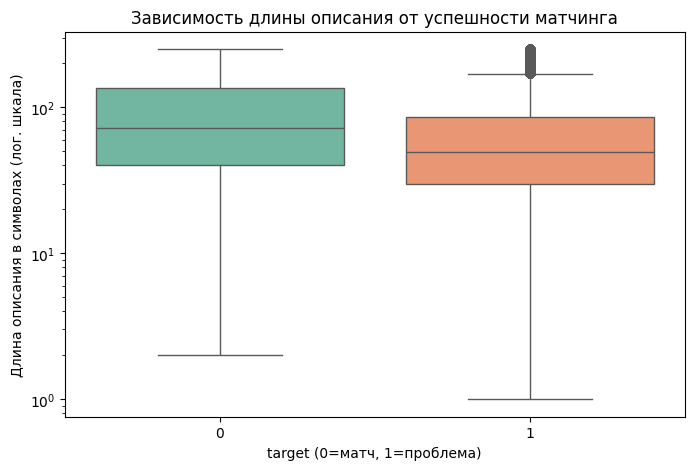

In [7]:
# Убедимся, что длина в символах есть
df_clean['len_chars'] = df_clean['supplier_room_name'].str.len()

# Если нет категории, создаём (0-99, 100-999, >=1000)
if 'cat_new' not in df_clean.columns:
    def cat_rooms(r):
        if r < 100: return '0-99'
        elif r < 1000: return '100-999'
        else: return '>=1000'
    df_clean['cat_new'] = df_clean['rooms_count'].apply(cat_rooms)

# 1. Средняя длина по группам
print("Средняя длина описания (символы) по группам отелей:")
print(df_clean.groupby('cat_new')['len_chars'].mean().round(1))

# 2. Общий график: длина vs target
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='target', y='len_chars', palette='Set2')
plt.yscale('log')
plt.xlabel('target (0=матч, 1=проблема)')
plt.ylabel('Длина описания в символах (лог. шкала)')
plt.title('Зависимость длины описания от успешности матчинга')
plt.show()

Доля описаний, содержащих цифры, по классам:
   target  frequency
0       0   0.397081
1       1   0.418489


/tmp/ipykernel_1218/2841473521.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=digit_freq, x='target', y='frequency', palette='Set2')


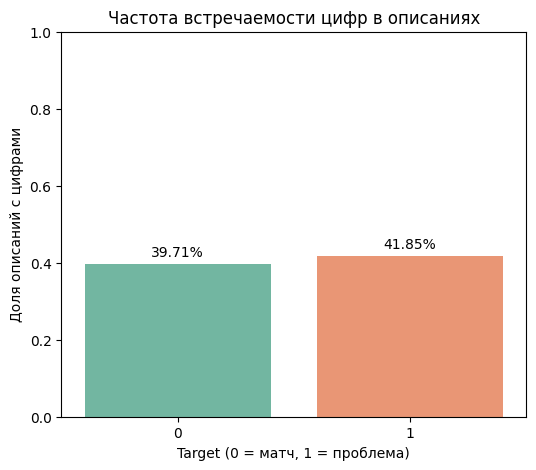

In [13]:
df_clean['has_digit'] = df_clean['supplier_room_name'].apply(lambda x: 1 if re.search(r'\d', str(x)) else 0)

digit_freq = df_clean.groupby('target')['has_digit'].mean().reset_index()
digit_freq.columns = ['target', 'frequency']

print("Доля описаний, содержащих цифры, по классам:")
print(digit_freq)

plt.figure(figsize=(6, 5))
sns.barplot(data=digit_freq, x='target', y='frequency', palette='Set2')
plt.ylim(0, 1)
plt.xlabel('Target (0 = матч, 1 = проблема)')
plt.ylabel('Доля описаний с цифрами')
plt.title('Частота встречаемости цифр в описаниях')
for i, row in digit_freq.iterrows():
    plt.text(i, row['frequency'] + 0.02, f"{row['frequency']:.2%}", ha='center')
plt.show()

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

def preprocess_text(text):
    if not isinstance(text, str):
        text = str(text) if text is not None else ''
    text = text.lower()
    text = re.sub(r'[^a-zA-Zа-яё\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['processed_text'] = df_clean['supplier_room_name'].apply(preprocess_text).fillna('').astype(str)

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    max_df=0.8,
    min_df=5
)

X = vectorizer.fit_transform(df_clean['processed_text'].tolist())
feature_names = vectorizer.get_feature_names_out()

mask_0 = (df_clean['target'] == 0).values
mask_1 = (df_clean['target'] == 1).values

X_0 = X[mask_0]
X_1 = X[mask_1]

mean_tfidf_0 = np.asarray(X_0.mean(axis=0)).flatten()
mean_tfidf_1 = np.asarray(X_1.mean(axis=0)).flatten()

def get_top_words(mean_vector, feature_names, top_n=20):
    sorted_idx = np.argsort(mean_vector)[::-1]
    top_indices = sorted_idx[:top_n]
    return [(feature_names[i], mean_vector[i]) for i in top_indices]

print("Топ-20 ключевых слов для target = 0 (матч):")
for word, score in get_top_words(mean_tfidf_0, feature_names):
    print(f"  {word}: {score:.4f}")

print("\nТоп-20 ключевых слов для target = 1 (проблема):")
for word, score in get_top_words(mean_tfidf_1, feature_names):
    print(f"  {word}: {score:.4f}")

diff = mean_tfidf_0 - mean_tfidf_1
sorted_diff_idx = np.argsort(np.abs(diff))[::-1]
print("\nТоп-20 слов, наиболее различающих классы (по абсолютной разности средних TF-IDF):")
for i in sorted_diff_idx[:20]:
    word = feature_names[i]
    diff_val = diff[i]
    direction = "матч (0)" if diff_val > 0 else "проблема (1)"
    print(f"  {word}: разность = {diff_val:.4f} (выше в классе {direction})")

Топ-20 ключевых слов для target = 0 (матч):
  не: 0.0599
  bed: 0.0576
  кровать: 0.0572
  room: 0.0524
  double: 0.0458
  included: 0.0454
  not: 0.0448
  not included: 0.0445
  кровать не: 0.0400
  не включена: 0.0400
  включена: 0.0398
  king: 0.0313
  child: 0.0295
  детская кровать: 0.0286
  детская: 0.0286
  view: 0.0273
  twin: 0.0272
  deluxe: 0.0254
  standard: 0.0239
  кровати: 0.0228

Топ-20 ключевых слов для target = 1 (проблема):
  room: 0.0541
  bed: 0.0405
  single: 0.0352
  view: 0.0329
  double: 0.0322
  suite: 0.0296
  кровать: 0.0273
  king: 0.0269
  deluxe: 0.0256
  twin: 0.0245
  with: 0.0219
  standard: 0.0202
  breakfast: 0.0199
  не: 0.0183
  superior: 0.0181
  sea: 0.0174
  and: 0.0170
  sea view: 0.0168
  номер: 0.0166
  family: 0.0166

Топ-20 слов, наиболее различающих классы (по абсолютной разности средних TF-IDF):
  не: разность = 0.0415 (выше в классе матч (0))
  not: разность = 0.0342 (выше в классе матч (0))
  not included: разность = 0.0341 (выше в клас

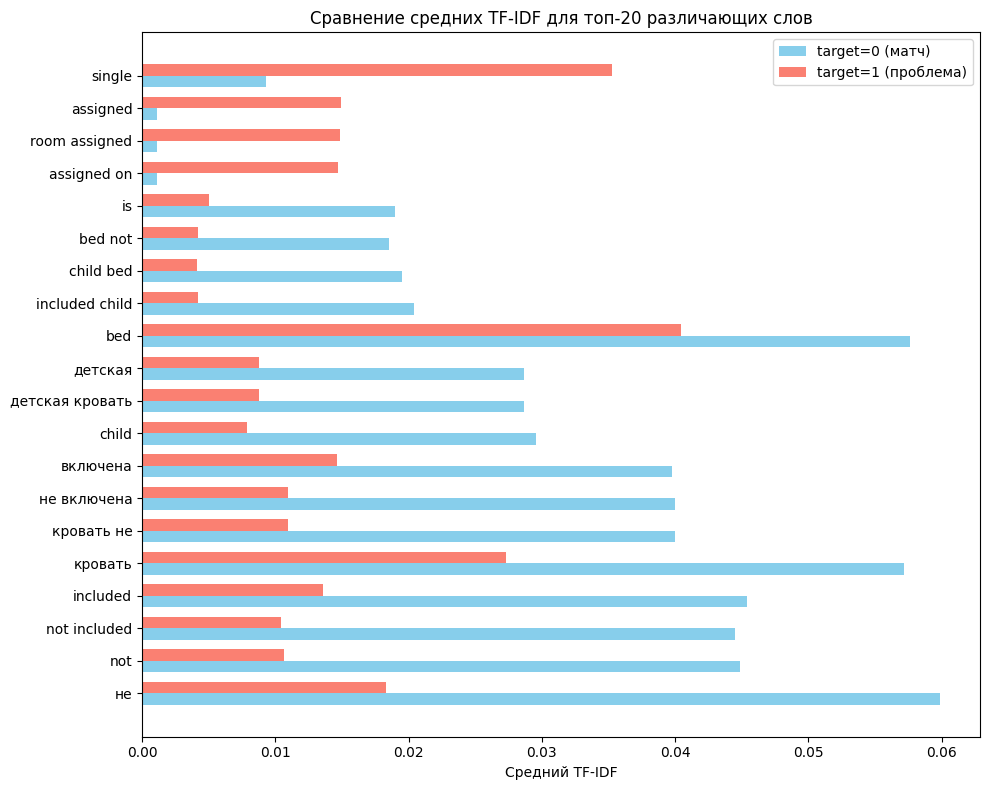

In [15]:
top_diff_indices = sorted_diff_idx[:20]
top_words = feature_names[top_diff_indices]

df_plot = pd.DataFrame({
    'word': top_words,
    'tfidf_0': mean_tfidf_0[top_diff_indices],
    'tfidf_1': mean_tfidf_1[top_diff_indices],
    'diff': diff[top_diff_indices]
})

df_plot = df_plot.sort_values('diff', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(df_plot))
width = 0.35

ax.barh(y_pos - width/2, df_plot['tfidf_0'], height=width, label='target=0 (матч)', color='skyblue')
ax.barh(y_pos + width/2, df_plot['tfidf_1'], height=width, label='target=1 (проблема)', color='salmon')

ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['word'])
ax.set_xlabel('Средний TF-IDF')
ax.set_title('Сравнение средних TF-IDF для топ-20 различающих слов')
ax.legend()

plt.tight_layout()
plt.show()